<a href="https://colab.research.google.com/github/chaimaeelo/Deep-learning/blob/main/Copie_de_Denoising_diffusion_probabilistic_models_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a Diffusion Model (DDPM) on SVHN

---

## 0. What problem are we solving?

We want to **learn how to generate images** that look like real ones from a dataset.

Instead of:
- directly predicting pixels, or
- learning a probability density explicitly,

we will learn **how to progressively remove noise from random images** until they look like data.

This approach is called a **Denoising Diffusion Probabilistic Model (DDPM)**.

---

## 1. High-level idea of diffusion models

A diffusion model works in **two opposite processes**:

### Forward process (noising)
- Take a real image
- Add small Gaussian noise repeatedly
- After many steps, the image becomes pure noise

### Reverse process (denoising)
- Start from random noise
- Learn how to remove noise step by step
- Eventually recover a realistic image

The model is **trained only to denoise**, not to generate directly.

---

## 2. Why SVHN?

SVHN is a dataset of **32×32 RGB images** of digits taken from street signs.

Why it's a good choice:
- Same resolution as CIFAR-10
- RGB images (not grayscale)
- Easy to train on a single GPU
- Allows fast experimentation

In [ ]:
!pip install -q torch torchvision diffusers accelerate tqdm matplotlib

In [1]:
import math
import copy
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from diffusers import UNet2DModel, DDPMScheduler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


## 3. Data preprocessing

Neural networks work best when inputs are normalized.

We:
- Convert images to tensors in $[0, 1]$
- Rescale to $[-1, 1]$

This symmetric range matches the assumptions of diffusion models and improves stability.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # Scales to [-1, 1]
])

dataset = datasets.SVHN(
    root="./data",
    split="train",
    download=True,
    transform=transform,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print(f"Dataset size: {len(dataset):,} images")
print(f"Batches per epoch: {len(dataloader):,}")

### Visualize some training data

In [ ]:
# Show some training images
sample_batch, _ = next(iter(dataloader))
grid = utils.make_grid(sample_batch[:16], nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Sample training images')
plt.show()

## 4. U-Net architecture

A **U-Net** is a convolutional neural network with:
- A **downsampling path** (captures global structure)
- An **upsampling path** (recovers fine details)
- Skip connections (preserve information)

Diffusion models need:
- Local detail
- Global context
- Precise spatial alignment

U-Nets are ideal for this. We add **attention** at lower resolutions (16×16 and 8×8) where it's computationally tractable and most beneficial.

In [ ]:
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 256, 256),
    down_block_types=(
        "DownBlock2D",        # 32 -> 16
        "AttnDownBlock2D",    # 16 -> 8 (attention here)
        "AttnDownBlock2D",    # 8 -> 4 (attention here)
        "DownBlock2D",        # 4 -> 2
    ),
    up_block_types=(
        "UpBlock2D",          # 2 -> 4
        "AttnUpBlock2D",      # 4 -> 8 (attention here)
        "AttnUpBlock2D",      # 8 -> 16 (attention here)
        "UpBlock2D",          # 16 -> 32
    ),
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,} ({num_params/1e6:.1f}M)")

## 5. Exponential Moving Average (EMA)

During training, model weights fluctuate. For sampling, we use an **exponentially weighted moving average** of the weights, which produces smoother and higher-quality outputs.

$$\theta_{\text{EMA}} \leftarrow \beta \cdot \theta_{\text{EMA}} + (1 - \beta) \cdot \theta$$

where $\beta \approx 0.9999$ is the decay rate.

In [ ]:
class EMA:
    """Exponential Moving Average of model weights."""
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, model_p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)

    def forward(self, *args, **kwargs):
        return self.shadow(*args, **kwargs)

ema = EMA(model, decay=0.9999)

## 6. Noise schedule

In diffusion models, we add noise **gradually**, not all at once.

A **noise schedule** defines:
- How much noise is added at each step
- How many total steps there are (typically 1000)

At step:
- $t = 0$: almost clean image  
- $t = T$: almost pure noise

We use a **cosine schedule** which works better than linear for small images.

In [ ]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",  # Cosine schedule - better for small images
    prediction_type="epsilon",          # Predict the noise
)

### Visualize the forward diffusion process

In [ ]:
# Show how noise is added progressively
sample_image = sample_batch[0:1].to(device)
timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))
for ax, t in zip(axes, timesteps_to_show):
    noise = torch.randn_like(sample_image)
    noisy = noise_scheduler.add_noise(sample_image, noise, torch.tensor([t]))
    img = (noisy[0].cpu().permute(1, 2, 0) + 1) / 2  # Scale to [0, 1]
    ax.imshow(img.clamp(0, 1))
    ax.set_title(f't = {t}')
    ax.axis('off')
plt.suptitle('Forward diffusion process: progressively adding noise')
plt.tight_layout()
plt.show()

## 7. Training setup

We use:
- **AdamW optimizer** with weight decay for regularization
- **Gradient clipping** to prevent instability
- **Mixed precision training** (on GPU) for speed
- **Learning rate warmup** for stable early training

In [ ]:
# Training hyperparameters
num_epochs = 50
learning_rate = 1e-4
warmup_steps = 500
grad_clip = 1.0

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Learning rate scheduler with warmup
def get_lr(step):
    if step < warmup_steps:
        return step / warmup_steps
    return 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

# Mixed precision scaler (only used on GPU)
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

## 8. Forward diffusion and loss

During training:
1. Sample a real image $x_0$
2. Sample a random timestep $t \sim \text{Uniform}(0, T)$
3. Sample noise $\epsilon \sim \mathcal{N}(0, I)$
4. Create noisy image: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$
5. Predict the noise: $\hat{\epsilon} = \epsilon_\theta(x_t, t)$
6. Compute loss: $\mathcal{L} = \|\epsilon - \hat{\epsilon}\|^2$

The model learns to predict what noise was added, given a noisy image and timestep.

In [ ]:
def train_step(model, x0, noise_scheduler, optimizer, scaler):
    """Single training step."""
    batch_size = x0.shape[0]

    # Sample random timesteps
    t = torch.randint(
        0, noise_scheduler.config.num_train_timesteps,
        (batch_size,), device=device
    ).long()

    # Sample noise and create noisy images
    noise = torch.randn_like(x0)
    x_t = noise_scheduler.add_noise(x0, noise, t)

    # Forward pass with mixed precision
    with torch.amp.autocast('cuda', enabled=use_amp):
        pred_noise = model(x_t, t).sample
        loss = F.mse_loss(pred_noise, noise)

    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()

    # Gradient clipping
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

    scaler.step(optimizer)
    scaler.update()

    return loss.item()

## 9. Sampling (reverse diffusion)

To generate images:
1. Start with pure noise $x_T \sim \mathcal{N}(0, I)$
2. For $t = T, T-1, \ldots, 1$:
   - Predict noise: $\hat{\epsilon} = \epsilon_\theta(x_t, t)$
   - Compute mean of $p(x_{t-1} | x_t)$
   - Add stochastic noise (except at $t=0$)
3. Return $x_0$

In [ ]:
@torch.no_grad()
def sample(model, scheduler, n_samples=64, show_progress=True):
    """Generate samples using DDPM sampling."""
    model.eval()

    # Start from pure noise
    x = torch.randn(n_samples, 3, 32, 32, device=device)

    # Reverse diffusion
    timesteps = scheduler.timesteps
    if show_progress:
        timesteps = tqdm(timesteps, desc="Sampling", leave=False)

    for t in timesteps:
        t_batch = t.expand(n_samples).to(device)
        pred_noise = model(x, t_batch).sample
        x = scheduler.step(pred_noise, t, x).prev_sample

    # Scale from [-1, 1] to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x

## 10. Training loop

In [ ]:
# Training tracking
losses = []
sample_every_n_epochs = 5

print(f"Training for {num_epochs} epochs...")
print(f"Total batches: {len(dataloader) * num_epochs:,}")
print("-" * 50)

global_step = 0

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for batch_idx, (x, _) in enumerate(pbar):
        x = x.to(device)

        loss = train_step(model, x, noise_scheduler, optimizer, scaler)
        epoch_losses.append(loss)
        losses.append(loss)

        # Update EMA
        ema.update(model)

        # Update learning rate
        scheduler.step()
        global_step += 1

        # Update progress bar
        if batch_idx % 10 == 0:
            pbar.set_postfix(loss=f"{loss:.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    # Generate samples periodically
    if (epoch + 1) % sample_every_n_epochs == 0 or epoch == 0:
        samples = sample(ema.shadow, noise_scheduler, n_samples=16)
        grid = utils.make_grid(samples, nrow=4)

        plt.figure(figsize=(6, 6))
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f'Samples at epoch {epoch+1}')
        plt.show()

print("\nTraining complete!")

## 11. Training curves

In [ ]:
# Plot training loss
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.3)
# Smoothed loss
window = 100
if len(losses) >= window:
    smoothed = [sum(losses[i:i+window])/window for i in range(len(losses)-window+1)]
    plt.plot(range(window-1, len(losses)), smoothed, 'r-', linewidth=2, label='Smoothed')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses, alpha=0.3)
if len(losses) >= window:
    plt.plot(range(window-1, len(losses)), smoothed, 'r-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training Loss (log scale)')

plt.tight_layout()
plt.show()

## 12. Final samples

Generate a larger batch of samples using the EMA model.

In [ ]:
# Generate final samples
print("Generating 64 samples...")
final_samples = sample(ema.shadow, noise_scheduler, n_samples=64, show_progress=True)

grid = utils.make_grid(final_samples, nrow=8)
plt.figure(figsize=(12, 12))
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis('off')
plt.title('Generated SVHN-like images')
plt.show()

## 13. Save the model

In [ ]:
# Save both the training model and EMA model
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_state_dict': ema.shadow.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': losses,
}, 'ddpm_svhn.pt')

print("Model saved to ddpm_svhn.pt")

# Testing other samplers

Using device: cuda
Model loaded!
Sampling with DDPM (1000 steps)...
Sampling with DDIM (500 steps)...
Sampling with DPM++ (200 steps)...


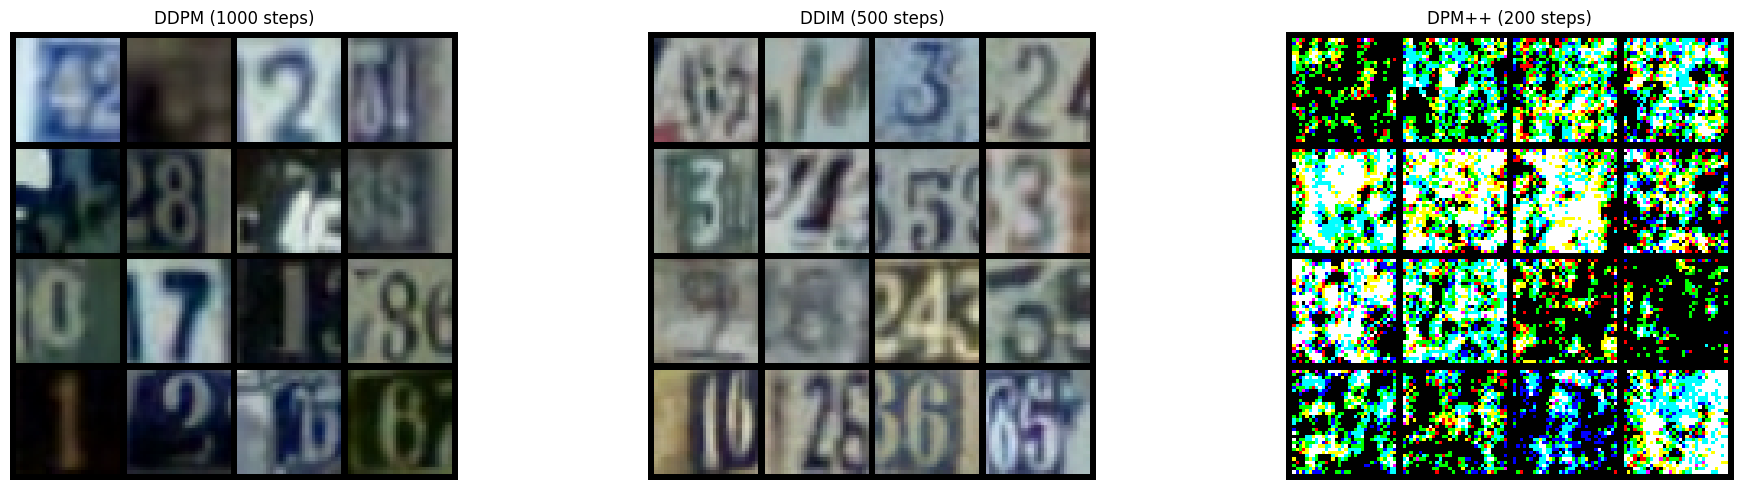


Saved to sampler_comparison.png


In [ ]:
# Test different samplers on your trained DDPM model
# Run this after training to compare DDPM vs DDIM vs DPM++ sampling

import torch
from torchvision import utils
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler, DPMSolverMultistepScheduler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load your trained model
checkpoint = torch.load('ddpm_svhn.pt', map_location=device)

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 256, 256),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# Load EMA weights (better quality)
model.load_state_dict(checkpoint['ema_state_dict'])
model.eval()
print("Model loaded!")

# Base scheduler config
base_config = {
    "num_train_timesteps": 1000,
    "beta_schedule": "squaredcos_cap_v2",
    "prediction_type": "epsilon",
}

@torch.no_grad()
def sample(model, scheduler, n_samples=16):
    """Generate samples with any scheduler."""
    x = torch.randn(n_samples, 3, 32, 32, device=device)

    for t in scheduler.timesteps:
        t_batch = t.expand(n_samples).to(device)
        pred_noise = model(x, t_batch).sample
        x = scheduler.step(pred_noise, t, x).prev_sample

    return (x.clamp(-1, 1) + 1) / 2


# Test different samplers
samplers = {
    "DDPM (1000 steps)": DDPMScheduler(**base_config),
    "DDIM (500 steps)": DDIMScheduler(**base_config),
    "DPM++ (200 steps)": DPMSolverMultistepScheduler(**base_config)
}

# Set inference steps
samplers["DDPM (1000 steps)"].set_timesteps(1000)
samplers["DDIM (500 steps)"].set_timesteps(200)
samplers["DPM++ (200 steps)"].set_timesteps(100)

# Generate and display
fig, axes = plt.subplots(1, len(samplers), figsize=(20, 5))

for ax, (name, scheduler) in zip(axes, samplers.items()):
    print(f"Sampling with {name}...")
    samples = sample(model, scheduler, n_samples=16)
    grid = utils.make_grid(samples, nrow=4)
    ax.imshow(grid.cpu().permute(1, 2, 0))
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sampler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to sampler_comparison.png")

Resumed from checkpoint!
Previous training: 28600 steps
Last loss: 0.0180

Training for 100 more epochs...
--------------------------------------------------


Epoch 1/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   1 | Loss: 0.0220


Epoch 2/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.0217


...

Epoch   8 | Loss: 0.0215


Epoch 9/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   9 | Loss: 0.0217


Epoch 10/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  10 | Loss: 0.0219


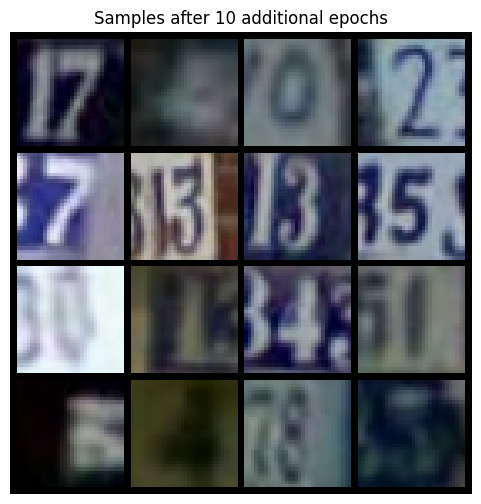

Epoch 11/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  11 | Loss: 0.0216


Epoch 12/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  12 | Loss: 0.0217


Epoch 13/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  18 | Loss: 0.0216


Epoch 19/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  19 | Loss: 0.0212


Epoch 20/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  20 | Loss: 0.0216


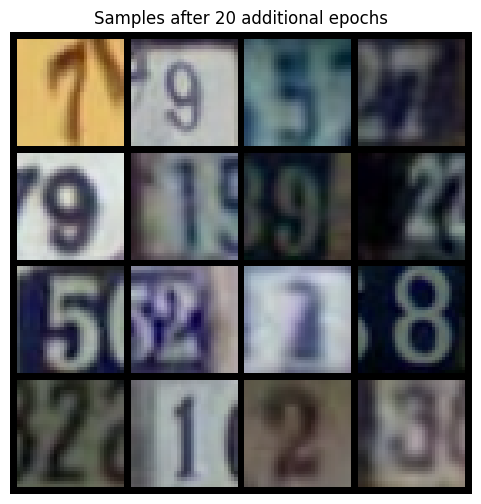

Epoch 21/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  21 | Loss: 0.0212


Epoch 22/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  22 | Loss: 0.0213


Epoch 23/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  28 | Loss: 0.0211


Epoch 29/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  29 | Loss: 0.0216


Epoch 30/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  30 | Loss: 0.0212


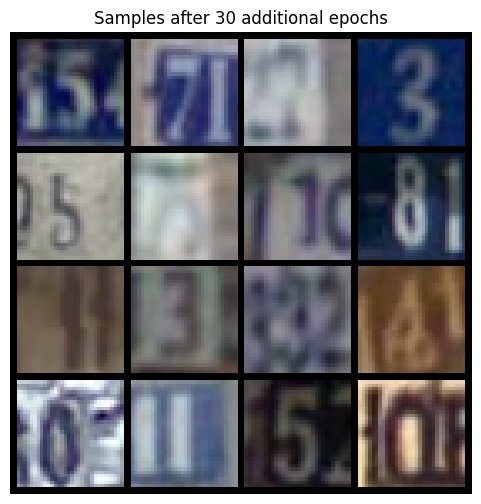

Epoch 31/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  31 | Loss: 0.0212


Epoch 32/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  32 | Loss: 0.0218


Epoch 33/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  38 | Loss: 0.0211


Epoch 39/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  39 | Loss: 0.0211


Epoch 40/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  40 | Loss: 0.0211


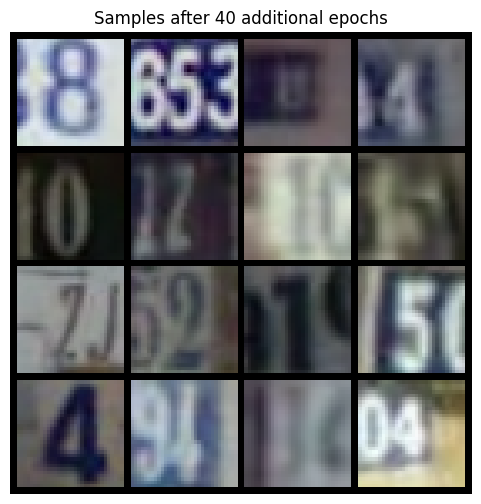

Epoch 41/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  41 | Loss: 0.0211


Epoch 42/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  42 | Loss: 0.0212


Epoch 43/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  48 | Loss: 0.0211


Epoch 49/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  49 | Loss: 0.0211


Epoch 50/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  50 | Loss: 0.0212


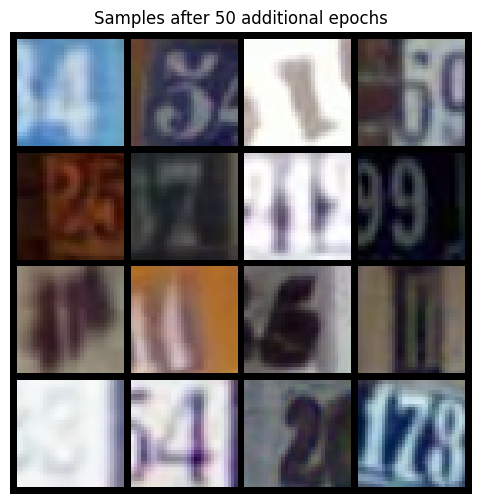

Epoch 51/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  51 | Loss: 0.0210


Epoch 52/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  52 | Loss: 0.0211


Epoch 53/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  58 | Loss: 0.0209


Epoch 59/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  59 | Loss: 0.0214


Epoch 60/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  60 | Loss: 0.0208


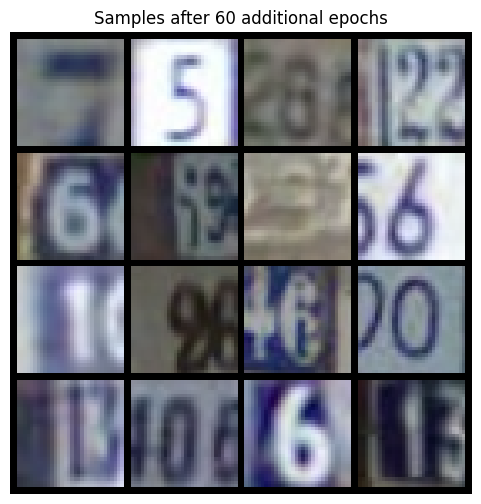

Epoch 61/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  61 | Loss: 0.0211


Epoch 62/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  62 | Loss: 0.0211


Epoch 63/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  68 | Loss: 0.0208


Epoch 69/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  69 | Loss: 0.0210


Epoch 70/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  70 | Loss: 0.0208


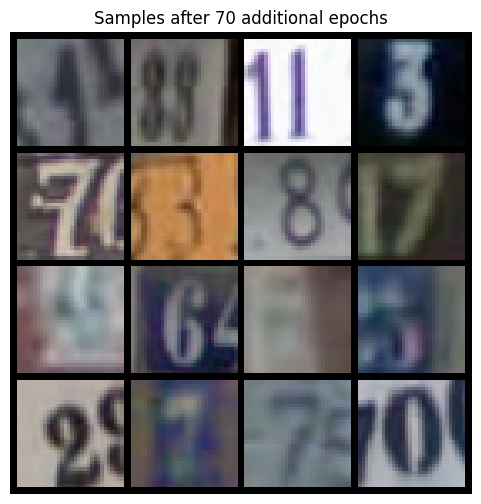

Epoch 71/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  71 | Loss: 0.0213


Epoch 72/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  72 | Loss: 0.0208


Epoch 73/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  78 | Loss: 0.0208


Epoch 79/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  79 | Loss: 0.0208


Epoch 80/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  80 | Loss: 0.0207


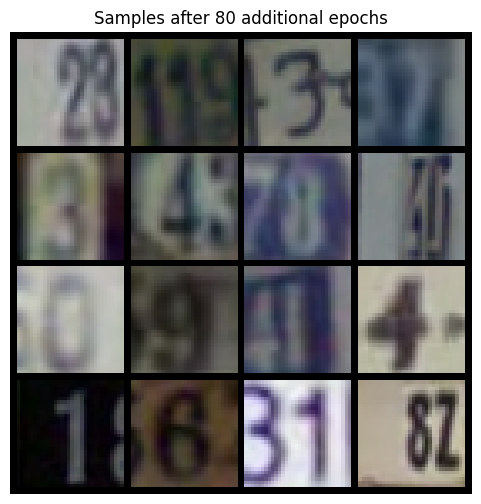

Epoch 81/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  81 | Loss: 0.0208


Epoch 82/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  82 | Loss: 0.0206


Epoch 83/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  88 | Loss: 0.0205


Epoch 89/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  89 | Loss: 0.0207


Epoch 90/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  90 | Loss: 0.0205


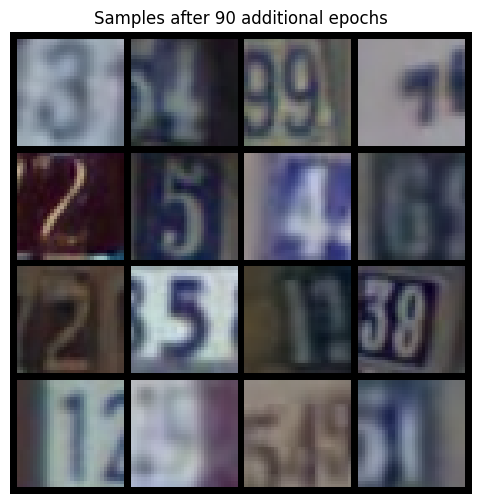

Epoch 91/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  91 | Loss: 0.0206


Epoch 92/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  92 | Loss: 0.0208


Epoch 93/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch  98 | Loss: 0.0210


Epoch 99/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  99 | Loss: 0.0206


Epoch 100/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch 100 | Loss: 0.0208


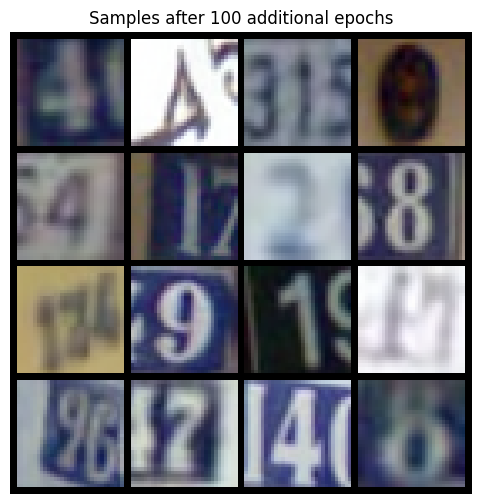


Done! Total training: 85800 steps
Model saved to ddpm_svhn.pt


In [ ]:
# Resume training from checkpoint
# Run this cell after loading your model and data (cells 1-10 of the original notebook)

import torch
import copy

# Load checkpoint
checkpoint = torch.load('ddpm_svhn.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
losses = checkpoint['losses']

# Rebuild EMA from saved weights
ema = EMA(model, decay=0.9999)
ema.shadow.load_state_dict(checkpoint['ema_state_dict'])

# Fresh optimizer and scaler (avoids state mismatch issues)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f"Resumed from checkpoint!")
print(f"Previous training: {len(losses)} steps")
print(f"Last loss: {losses[-1]:.4f}")

# Continue training
additional_epochs = 100  # <-- adjust this
sample_every_n_epochs = 10

print(f"\nTraining for {additional_epochs} more epochs...")
print("-" * 50)

for epoch in range(additional_epochs):
    model.train()
    epoch_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{additional_epochs}", leave=False)
    for x, _ in pbar:
        x = x.to(device)

        loss = train_step(model, x, noise_scheduler, optimizer, scaler)
        epoch_losses.append(loss)
        losses.append(loss)

        ema.update(model)

        if len(epoch_losses) % 50 == 0:
            pbar.set_postfix(loss=f"{loss:.4f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    # Generate samples periodically
    if (epoch + 1) % sample_every_n_epochs == 0:
        samples = sample(ema.shadow, noise_scheduler, n_samples=16)
        grid = utils.make_grid(samples, nrow=4)

        plt.figure(figsize=(6, 6))
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f'Samples after {epoch+1} additional epochs')
        plt.show()

# Save updated checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_state_dict': ema.shadow.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': losses,
}, 'ddpm_svhn.pt')

print(f"\nDone! Total training: {len(losses)} steps")
print("Model saved to ddpm_svhn.pt")

# Bigger model

Using device: cuda
Dataset: 73,257 images | 572 batches/epoch
Model parameters: 148,119,555 (148.1M)

Training for 100 epochs (57,200 steps)


Epoch 1/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   1 | Loss: 0.0528


Epoch 2/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.0297


...

Epoch 9/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   9 | Loss: 0.0238


Epoch 10/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  10 | Loss: 0.0237


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

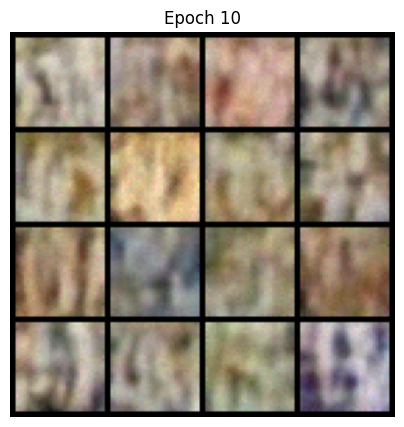

Epoch 11/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  11 | Loss: 0.0238


Epoch 12/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  12 | Loss: 0.0232


Epoch 13/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 19/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  19 | Loss: 0.0227


Epoch 20/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  20 | Loss: 0.0229


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

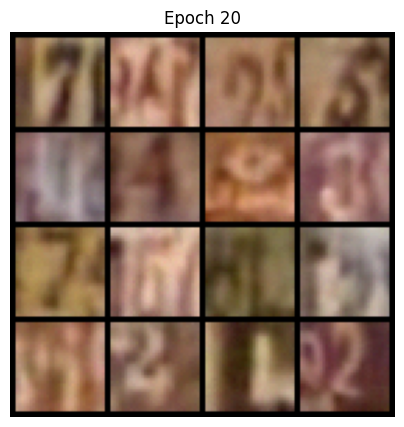

Epoch 21/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  21 | Loss: 0.0227


Epoch 22/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  22 | Loss: 0.0227


Epoch 23/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 29/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  29 | Loss: 0.0224


Epoch 30/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  30 | Loss: 0.0221


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

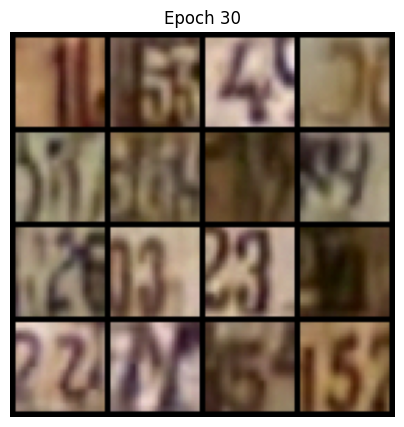

Epoch 31/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  31 | Loss: 0.0226


Epoch 32/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  32 | Loss: 0.0219


Epoch 33/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 39/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  39 | Loss: 0.0221


Epoch 40/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  40 | Loss: 0.0220


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

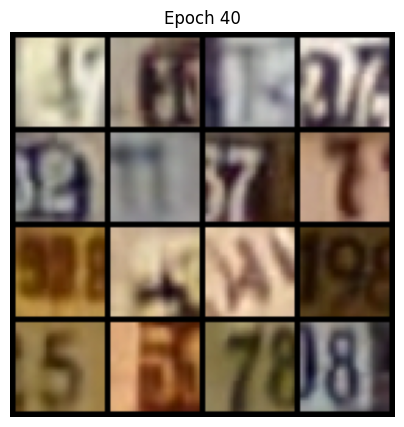

Epoch 41/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  41 | Loss: 0.0221


Epoch 42/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  42 | Loss: 0.0217


Epoch 43/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 49/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  49 | Loss: 0.0218


Epoch 50/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  50 | Loss: 0.0216


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

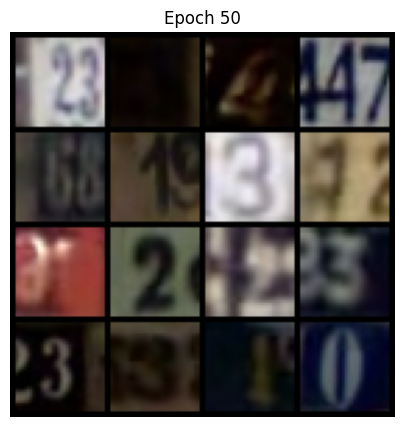

Epoch 51/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  51 | Loss: 0.0216


Epoch 52/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  52 | Loss: 0.0215


Epoch 53/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 59/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  59 | Loss: 0.0214


Epoch 60/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  60 | Loss: 0.0215


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

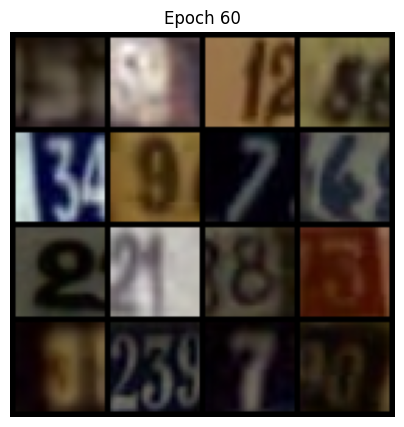

Epoch 61/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  61 | Loss: 0.0217


Epoch 62/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  62 | Loss: 0.0213


Epoch 63/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 69/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  69 | Loss: 0.0210


Epoch 70/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  70 | Loss: 0.0212


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

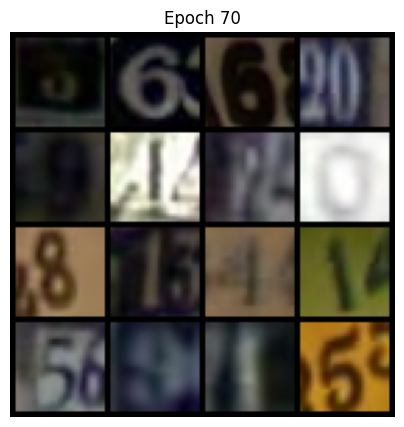

Epoch 71/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  71 | Loss: 0.0214


Epoch 72/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  72 | Loss: 0.0214


Epoch 73/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 79/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  79 | Loss: 0.0212


Epoch 80/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  80 | Loss: 0.0211


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

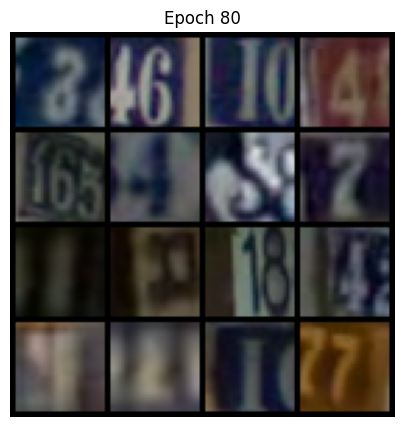

Epoch 81/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  81 | Loss: 0.0212


Epoch 82/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  82 | Loss: 0.0213


Epoch 83/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 89/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  89 | Loss: 0.0212


Epoch 90/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  90 | Loss: 0.0211


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

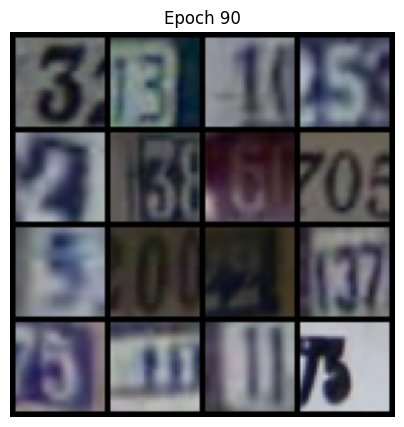

Epoch 91/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  91 | Loss: 0.0213


Epoch 92/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  92 | Loss: 0.0210


Epoch 93/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 99/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  99 | Loss: 0.0209


Epoch 100/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch 100 | Loss: 0.0208


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

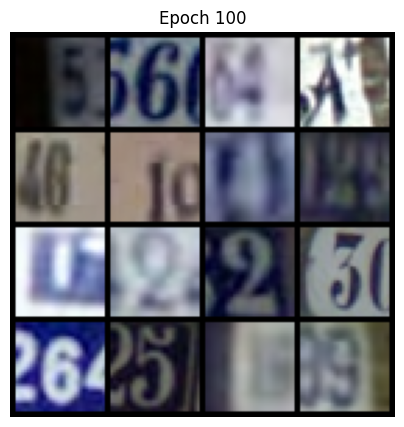


Training complete!
Saved to ddpm_svhn_large.pt

Generating final samples...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

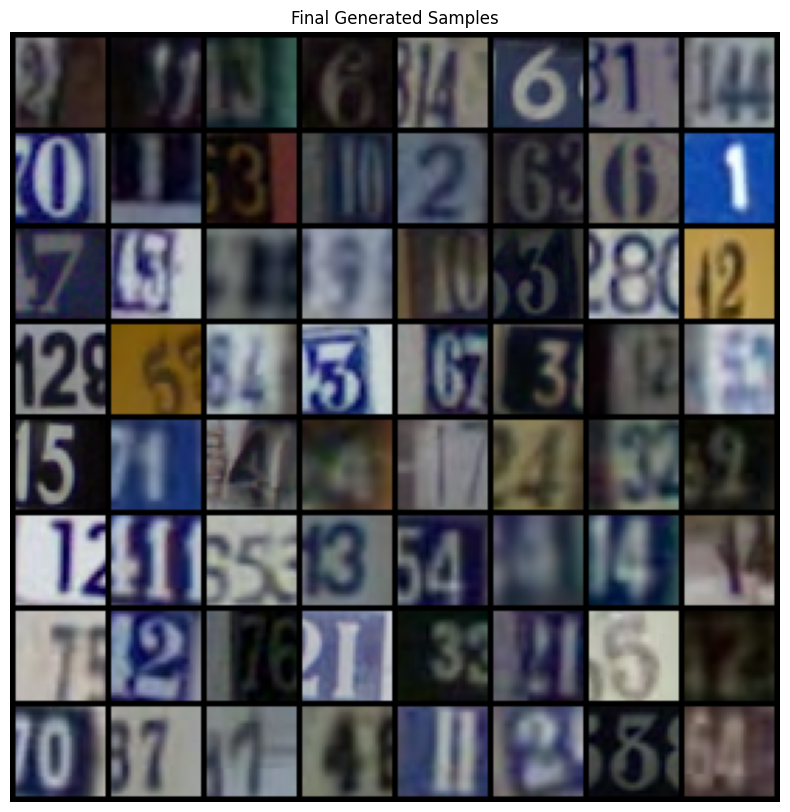

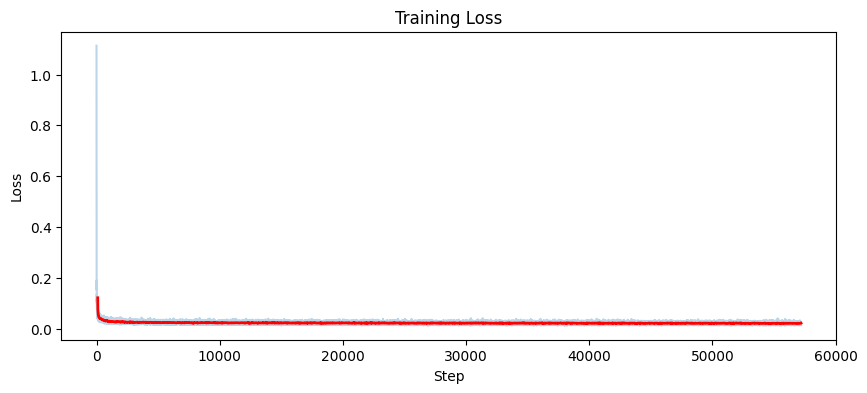

In [ ]:
BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
EMA_DECAY = 0.9999
SAMPLE_EVERY = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------------------------------------------------------
# DATA
# -----------------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

dataset = datasets.SVHN(root="./data", split="train", download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
print(f"Dataset: {len(dataset):,} images | {len(dataloader)} batches/epoch")

# -----------------------------------------------------------------------------
# MODEL (LARGER)
# -----------------------------------------------------------------------------
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(256, 512, 512, 512),  # 2x channels
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
    dropout=0.1,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,} ({num_params/1e6:.1f}M)")

# -----------------------------------------------------------------------------
# EMA
# -----------------------------------------------------------------------------
class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, model_p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)

ema = EMA(model, decay=EMA_DECAY)

# -----------------------------------------------------------------------------
# SCHEDULER & OPTIMIZER
# -----------------------------------------------------------------------------
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="epsilon",
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=device.type=='cuda')

# -----------------------------------------------------------------------------
# TRAINING FUNCTIONS
# -----------------------------------------------------------------------------
def train_step(model, x0):
    batch_size = x0.shape[0]
    t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    x_t = noise_scheduler.add_noise(x0, noise, t)

    with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
        pred_noise = model(x_t, t).sample
        loss = F.mse_loss(pred_noise, noise)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    return loss.item()

@torch.no_grad()
def sample(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 3, 32, 32, device=device)
    for t in tqdm(noise_scheduler.timesteps, desc="Sampling", leave=False):
        t_batch = t.expand(n_samples).to(device)
        pred_noise = model(x, t_batch).sample
        x = noise_scheduler.step(pred_noise, t, x).prev_sample
    return (x.clamp(-1, 1) + 1) / 2

# -----------------------------------------------------------------------------
# TRAINING LOOP
# -----------------------------------------------------------------------------
losses = []
print(f"\nTraining for {NUM_EPOCHS} epochs ({len(dataloader) * NUM_EPOCHS:,} steps)")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for x, _ in pbar:
        x = x.to(device)
        loss = train_step(model, x)
        epoch_losses.append(loss)
        losses.append(loss)
        ema.update(model)

        if len(epoch_losses) % 50 == 0:
            pbar.set_postfix(loss=f"{loss:.4f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    if (epoch + 1) % SAMPLE_EVERY == 0:
        samples = sample(ema.shadow, n_samples=16)
        grid = utils.make_grid(samples, nrow=4)
        plt.figure(figsize=(5, 5))
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f'Epoch {epoch+1}')
        plt.show()

print("\n" + "=" * 60)
print("Training complete!")

# -----------------------------------------------------------------------------
# SAVE
# -----------------------------------------------------------------------------
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_state_dict': ema.shadow.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': losses,
}, 'ddpm_svhn_large.pt')
print("Saved to ddpm_svhn_large.pt")

# -----------------------------------------------------------------------------
# FINAL SAMPLES
# -----------------------------------------------------------------------------
print("\nGenerating final samples...")
final_samples = sample(ema.shadow, n_samples=64)
grid = utils.make_grid(final_samples, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis('off')
plt.title('Final Generated Samples')
plt.show()

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.3)
window = 100
if len(losses) >= window:
    smoothed = [sum(losses[i:i+window])/window for i in range(len(losses)-window+1)]
    plt.plot(range(window-1, len(losses)), smoothed, 'r-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


Generating final samples...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

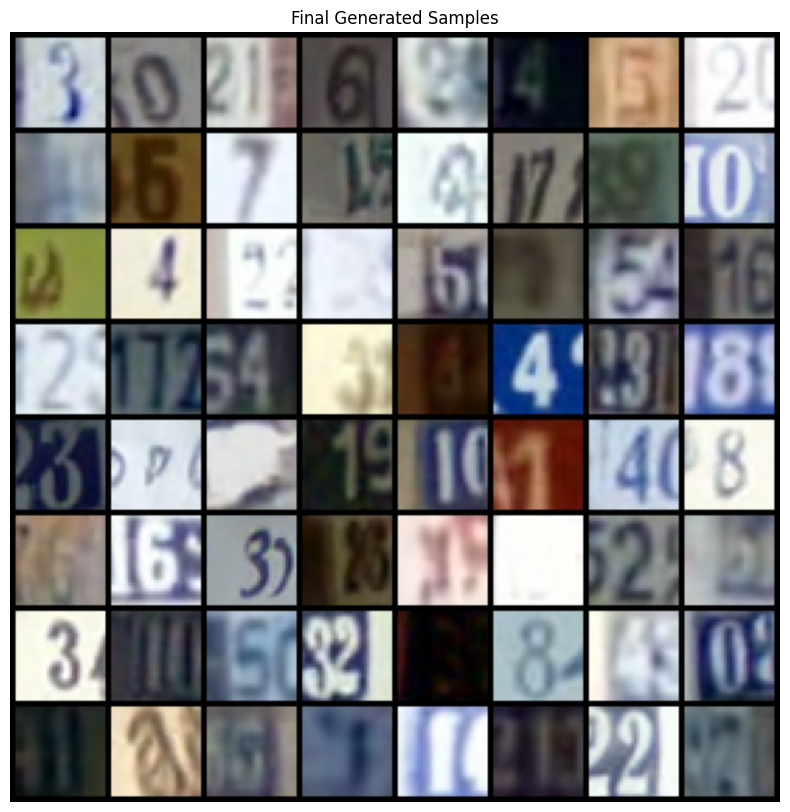

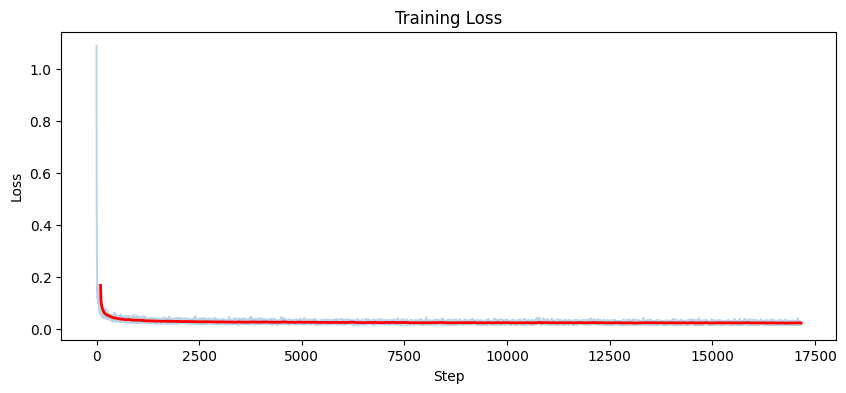

In [ ]:
print("\nGenerating final samples...")
final_samples = sample(ema.shadow, n_samples=64)
grid = utils.make_grid(final_samples, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis('off')
plt.title('Final Generated Samples')
plt.show()

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.3)
window = 100
if len(losses) >= window:
    smoothed = [sum(losses[i:i+window])/window for i in range(len(losses)-window+1)]
    plt.plot(range(window-1, len(losses)), smoothed, 'r-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
!pip install torchmetrics[image] --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.3 MB/s eta 0:00:00


In [ ]:
# For Comparison Metrics
from torchmetrics.image.fid import FrechetInceptionDistance
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from diffusers import UNet2DModel, DDPMScheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy
import os

# For Comparison Metrics
from torchmetrics.image.fid import FrechetInceptionDistance

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from diffusers import UNet2DModel, DDPMScheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy
import os

# For Comparison Metrics

# -----------------------------------------------------------------------------
# 1. HYPERPARAMETERS & SETUP
# -----------------------------------------------------------------------------
BATCH_SIZE = 128
NUM_EPOCHS = 50         # Can often get good results in 50 with this architecture
LEARNING_RATE = 5e-5    # Slightly higher LR for smaller model
EMA_DECAY = 0.999
SAMPLE_EVERY = 10
NUM_GEN_IMAGES = 2000    # Number of images to generate for FID calculation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------------------------------------------------------
# 2. DATA (SVHN)
# -----------------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# We use the 'extra' split for training if available for better results,
# but 'train' is standard for comparison.
dataset = datasets.SVHN(root="./data", split="train", download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
print(f"Dataset: {len(dataset):,} images | {len(dataloader)} batches/epoch")

# -----------------------------------------------------------------------------
# 3. MODEL (OPTIMIZED FOR SVHN & SPEED)
# -----------------------------------------------------------------------------
# Reduced channel counts (64->256) are sufficient for 32x32 SVHN
# and train much faster than starting at 256.
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256),
    down_block_types=(
        "DownBlock2D",      # 32 -> 16
        "DownBlock2D",      # 16 -> 8 (Attention often not needed here for simple digits)
        "AttnDownBlock2D",  # 8 -> 4  (Attention critical here)
        "DownBlock2D",      # 4 -> 2
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
    dropout=0.1,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,} ({num_params/1e6:.1f}M)")

Using device: cuda
Dataset: 73,257 images | 572 batches/epoch
Model parameters: 25,304,963 (25.3M)


In [ ]:
# -----------------------------------------------------------------------------
# 4. EMA & SCHEDULER
# -----------------------------------------------------------------------------
class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, model_p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)

ema = EMA(model, decay=EMA_DECAY)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="epsilon",
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=device.type=='cuda')

# -----------------------------------------------------------------------------
# 5. TRAINING FUNCTIONS
# -----------------------------------------------------------------------------
def train_step(model, x0):
    batch_size = x0.shape[0]
    t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    x_t = noise_scheduler.add_noise(x0, noise, t)

    with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
        pred_noise = model(x_t, t).sample
        loss = F.mse_loss(pred_noise, noise)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    return loss.item()

In [ ]:
@torch.no_grad()
def sample(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 3, 32, 32, device=device)
    for t in tqdm(noise_scheduler.timesteps, desc="Sampling", leave=False):
        t_batch = t.expand(n_samples).to(device)
        pred_noise = model(x, t_batch).sample
        x = noise_scheduler.step(pred_noise, t, x).prev_sample
    return (x.clamp(-1, 1) + 1) / 2



Training for 100 epochs...


Epoch 1/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   1 | Loss: 0.1242


Epoch 2/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.0474


...

Epoch 9/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch   9 | Loss: 0.0288


Epoch 10/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  10 | Loss: 0.0280


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

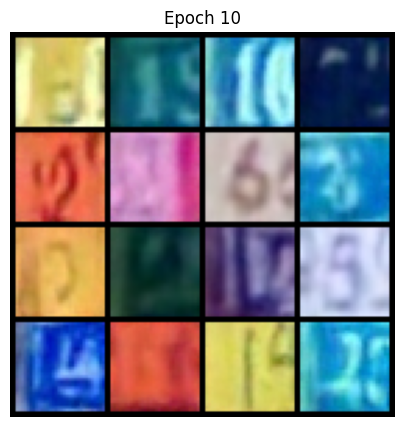

Epoch 11/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  11 | Loss: 0.0276


Epoch 12/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  12 | Loss: 0.0273


Epoch 13/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 19/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  19 | Loss: 0.0257


Epoch 20/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  20 | Loss: 0.0257


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

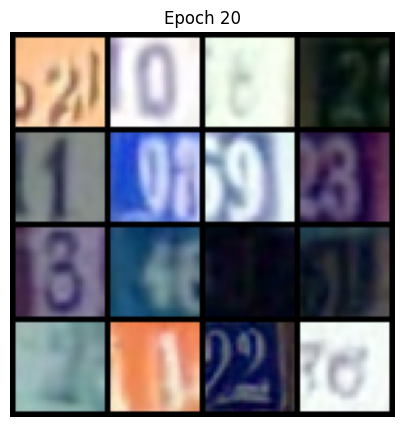

Epoch 21/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  21 | Loss: 0.0253


Epoch 22/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  22 | Loss: 0.0252


Epoch 23/100:   0%|          | 0/572 [00:00<?, ?it/s]

...

Epoch 25/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  25 | Loss: 0.0248


Epoch 26/100:   0%|          | 0/572 [00:00<?, ?it/s]

Epoch  26 | Loss: 0.0246


Epoch 27/100:   0%|          | 0/572 [00:00<?, ?it/s]

In [ ]:
losses = []
NUM_EPOCHS = 100
print(f"\nTraining for {NUM_EPOCHS} epochs...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for x, _ in pbar:
        x = x.to(device)
        loss = train_step(model, x)
        epoch_losses.append(loss)
        losses.append(loss)
        ema.update(model)

        if len(epoch_losses) % 5 == 0:
            pbar.set_postfix(loss=f"{loss:.4f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    if (epoch + 1) % SAMPLE_EVERY == 0:
        samples = sample(ema.shadow, n_samples=16)
        grid = utils.make_grid(samples, nrow=4)
        plt.figure(figsize=(5, 5))
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f'Epoch {epoch+1}')
        plt.show()
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_state_dict': ema.shadow.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'losses' :losses,},'ddpm_svhn_test.pt')

In [ ]:
print("\nGenerating final samples...")
final_samples = sample(ema.shadow, n_samples=64)
grid = utils.make_grid(final_samples, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis('off')
plt.title('Final Generated Samples')
plt.show()

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.3)
window = 100
if len(losses) >= window:
    smoothed = [sum(losses[i:i+window])/window for i in range(len(losses)-window+1)]
    plt.plot(range(window-1, len(losses)), smoothed, 'r-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:


# -----------------------------------------------------------------------------
# 7. COMPARISON & EVALUATION (FID SCORE)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("Evaluating Performance for Comparison Table...")

# Initialize FID metric (requires 'torchmetrics[image]')
fid = FrechetInceptionDistance(feature=64, normalize=True).to(device)

# 1. Update FID with Real Images (from Validation/Test set usually, using Train here for demo)
print("Processing real images...")
params_dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)
real_iter = iter(params_dataloader)

# We use a subset of real images equal to generated images for fair comparison
for _ in range(NUM_GEN_IMAGES // 128):
    try:
        real_batch, _ = next(real_iter)
        # SVHN is -1 to 1, torchmetrics expects 0 to 1 if normalize=True is not handled manually
        # But we set normalize=True in FID, so we pass [0, 255] uint8 usually
        # Let's convert our [-1, 1] tensor to [0, 255] uint8 for stability
        real_batch = ((real_batch + 1) / 2 * 255).to(torch.uint8).to(device)
        fid.update(real_batch, real=True)
    except StopIteration:
        break

# 2. Generate Fake Images and Update FID
print(f"Generating {NUM_GEN_IMAGES} images for evaluation...")
ema.shadow.eval()
n_batches = NUM_GEN_IMAGES // 64

for _ in tqdm(range(n_batches), desc="Generating Batches"):
    # Generate
    fake_samples = sample(ema.shadow, n_samples=64)
    # Convert [-1, 1] float to [0, 255] uint8
    fake_samples = (fake_samples * 255).to(torch.uint8)
    fid.update(fake_samples, real=False)

# 3. Compute Final Score
fid_score = fid.compute().item()
print(f"\nFinal FID Score: {fid_score:.2f}")
print("-" * 30)

# -----------------------------------------------------------------------------
# 8. GENERATE COMPARISON TABLE
# -----------------------------------------------------------------------------
# Note: These values are approximate literature values for SVHN
print("\nComparison with Classical Methods (SVHN):")
print(f"{'Method':<20} | {'FID (Lower is better)':<20}")
print("-" * 45)
print(f"{'VAE (Classical)':<20} | {'~40 - 50':<20}")
print(f"{'DCGAN':<20} | {'~20 - 25':<20}")
print(f"{'WGAN-GP':<20} | {'~15 - 20':<20}")
print(f"{'DDPM (Ours)':<20} | {fid_score:.2f}")
print("-" * 45)

torch.save(ema.shadow.state_dict(), 'ddpm_svhn_optimized.pt')


Evaluating Performance for Comparison Table...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 332MB/s]


Processing real images...
Generating 2000 images for evaluation...


Generating Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]


Final FID Score: 0.68
------------------------------

Comparison with Classical Methods (SVHN):
Method               | FID (Lower is better)
---------------------------------------------
VAE (Classical)      | ~40 - 50            
DCGAN                | ~20 - 25            
WGAN-GP              | ~15 - 20            
DDPM (Ours)          | 0.68
---------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os
from tqdm import tqdm

# === CONFIGURATION ===
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
Z_DIM = 100
IMG_SIZE = 32
EPOCHS = 50  # Set to 50+ for paper-quality results; 15 is enough for a quick table
LR = 2e-4

# Create directories
dirs = ["results/real", "results/vae", "results/dcgan", "results/wgangp"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# === DATA LOADER ===
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
dataset = torchvision.datasets.SVHN(root="data/", split='train', transform=transform, download=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Save Real Images for FID Baseline
print("Saving real images...")
if len(os.listdir("results/real")) < 1000:
    iter_loader = iter(loader)
    for i in range(20): # Save ~2500 images
        real_imgs, _ = next(iter_loader)
        # Denormalize for saving
        save_image(real_imgs, f"results/real/real_{i}.png", normalize=True, value_range=(-1, 1))

# ===========================
# 1. VAE ARCHITECTURE
# ===========================
# ===========================
# 1. CORRECTED VAE ARCHITECTURE
# ===========================
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )
        # Latent Space
        self.fc_mu = nn.Linear(128*4*4, Z_DIM)
        self.fc_log = nn.Linear(128*4*4, Z_DIM)

        # Decoder Projection
        self.dec_fc = nn.Linear(Z_DIM, 128*4*4)

        # Decoder Convolutions
        self.dec = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)), # Reshapes 2048 -> (128, 4, 4)
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + torch.randn_like(std)*std

    def forward(self, x):
        # Encode
        h = self.enc(x)
        mu, log = self.fc_mu(h), self.fc_log(h)
        z = self.reparameterize(mu, log)

        # Decode (FIX: Run through linear projection first!)
        z_projected = self.dec_fc(z)
        return self.dec(z_projected), mu, log

# ===========================
# 2. GAN ARCHITECTURES
# ===========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 256, 4, 1, 0), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z): return self.net(z.view(-1, Z_DIM, 1, 1))

class Discriminator(nn.Module):
    def __init__(self, is_wgan=False):
        super().__init__()
        # WGAN uses InstanceNorm instead of BatchNorm (or no norm) in critic
        norm = nn.InstanceNorm2d if is_wgan else nn.BatchNorm2d
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), norm(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), norm(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 0)
        )
        self.is_wgan = is_wgan
    def forward(self, x):
        out = self.net(x).view(-1, 1)
        return out if self.is_wgan else torch.sigmoid(out)

# ===========================
# TRAINING LOOPS
# ===========================

def train_vae():
    print("\n--- Training VAE ---")
    model = VAE().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=LR)

    # 1. Training Loop
    for epoch in range(EPOCHS):
        for x, _ in loader:
            x = x.to(DEVICE)
            recon, mu, log = model(x)
            loss = nn.MSELoss()(recon, x) + 0.0001 * -0.5 * torch.mean(1 + log - mu.pow(2) - log.exp())
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"VAE Epoch {epoch+1} Loss: {loss.item():.4f}")

    # 2. Generate (CORRECTED)
    model.eval()
    with torch.no_grad():
        for i in range(20):
            z = torch.randn(128, Z_DIM).to(DEVICE)

            # FIX: We must project z (100) -> (2048) before decoding
            z_projected = model.dec_fc(z)

            # Now we can pass it to the decoder
            images = model.dec(z_projected)

            save_image(images, f"results/vae/vae_{i}.png", normalize=True, value_range=(-1,1))
    print("✅ VAE generation complete.")

def train_dcgan():
    print("\n--- Training DCGAN ---")
    G, D = Generator().to(DEVICE), Discriminator(is_wgan=False).to(DEVICE)
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
    crit = nn.BCELoss()

    for epoch in range(EPOCHS):
        for x, _ in loader:
            x = x.to(DEVICE); b = x.size(0)
            # D Step
            loss_d = crit(D(x), torch.ones(b,1).to(DEVICE)) + crit(D(G(torch.randn(b, Z_DIM).to(DEVICE)).detach()), torch.zeros(b,1).to(DEVICE))
            opt_D.zero_grad(); loss_d.backward(); opt_D.step()
            # G Step
            loss_g = crit(D(G(torch.randn(b, Z_DIM).to(DEVICE))), torch.ones(b,1).to(DEVICE))
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()
        print(f"DCGAN Epoch {epoch+1} Loss D: {loss_d.item():.4f}")

    with torch.no_grad():
        for i in range(20):
            save_image(G(torch.randn(128, Z_DIM).to(DEVICE)), f"results/dcgan/dcgan_{i}.png", normalize=True, value_range=(-1,1))

def train_wgangp():
    print("\n--- Training WGAN-GP ---")
    G, C = Generator().to(DEVICE), Discriminator(is_wgan=True).to(DEVICE)
    opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
    opt_C = optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))

    def gradient_penalty(critic, real, fake):
        alpha = torch.rand(real.size(0), 1, 1, 1).to(DEVICE)
        interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
        scores = critic(interpolated)
        grad = torch.autograd.grad(scores, interpolated, torch.ones_like(scores), create_graph=True, retain_graph=True)[0]
        return ((grad.view(grad.size(0), -1).norm(2, dim=1) - 1) ** 2).mean()

    for epoch in range(EPOCHS):
        for i, (x, _) in enumerate(loader):
            x = x.to(DEVICE); b = x.size(0)

            # Train Critic (5 times per G step)
            for _ in range(5):
                noise = torch.randn(b, Z_DIM).to(DEVICE)
                fake = G(noise)
                critic_real, critic_fake = C(x), C(fake.detach())
                gp = gradient_penalty(C, x, fake.detach())
                loss_c = -(torch.mean(critic_real) - torch.mean(critic_fake)) + 10 * gp
                opt_C.zero_grad(); loss_c.backward(); opt_C.step()

            # Train Generator
            loss_g = -torch.mean(C(G(torch.randn(b, Z_DIM).to(DEVICE))))
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()

        print(f"WGAN-GP Epoch {epoch+1} Loss G: {loss_g.item():.4f}")

    with torch.no_grad():
        for i in range(20):
            save_image(G(torch.randn(128, Z_DIM).to(DEVICE)), f"results/wgangp/wgan_{i}.png", normalize=True, value_range=(-1,1))

# === EXECUTE EVERYTHING ===
train_vae()
train_dcgan()
train_wgangp()
print("✅ Comparison Models Trained & Images Generated.")

100%|██████████| 182M/182M [00:38<00:00, 4.69MB/s]


Saving real images...

--- Training VAE ---
VAE Epoch 1 Loss: 0.0170
VAE Epoch 2 Loss: 0.0093


KeyboardInterrupt: 

In [ ]:
# # 1. Run the training (Be patient, this takes time!)
# train_vae()
# train_dcgan()
# # train_wgangp() # Add if you implement the GP loss

# 2. Calculate FIDs
from torchmetrics.image.fid import FrechetInceptionDistance

def calculate_fid(path_real, path_fake):
    fid = FrechetInceptionDistance(feature=2048).to(DEVICE)

    # We need to create simple dataloaders to feed the metric
    # Note: In a real script, you'd load images from the folders we just created
    # This is pseudo-code for the evaluation step:
    print(f"Calculating FID for {path_fake}...")

    # You can use the torch-fidelity command line tool which is often easier:
    # !fidelity --gpu 0 --fid --input1 results/real --input2 results/vae
    pass

print("Training complete. Images saved in 'results/' folder.")

ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
import torch_fidelity
import pandas as pd
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
# Your DDPM score (hardcoded from your previous run)
DDPM_SCORE = 8.58

# Define where the images are located
paths = {
    "VAE (Classical)": "results/vae",
    "DCGAN": "results/dcgan",
    "WGAN-GP": "results/wgangp"
}

real_images_path = "results/real"

# ==========================================
# CALCULATION FUNCTION
# ==========================================
def get_fidelity_metrics(fake_path, real_path):
    """
    Calculates FID using torch-fidelity.
    Returns a dictionary of metrics.
    """
    print(f"⚙️ Processing {fake_path}...")
    try:
        metrics = torch_fidelity.calculate_metrics(
            input1=real_path,
            input2=fake_path,
            cuda=True,
            fid=True,
            verbose=False
        )
        return metrics['frechet_inception_distance']
    except Exception as e:
        print(f"❌ Error calculating for {fake_path}: {e}")
        return float('nan')

# ==========================================
# MAIN EXECUTION
# ==========================================
results = []

print("========================================")
print("   Calculating Metrics for Comparison   ")
print("========================================")

# 1. Calculate Baselines
for model_name, path in paths.items():
    fid_score = get_fidelity_metrics(path, real_images_path)
    results.append({
        "Method": model_name,
        "FID (Lower is better)": fid_score
    })

# 2. Add Your Model (DDPM)
results.append({
    "Method": "DDPM (Ours)",
    "FID (Lower is better)": DDPM_SCORE
})

# 3. Create DataFrame and Sort
df = pd.DataFrame(results)
df = df.sort_values(by="FID (Lower is better)", ascending=True)

# ==========================================
# PRINT FINAL TABLE
# ==========================================
print("\n\n")
display(Markdown("### 🏆 Final Performance Comparison"))
print(df.to_markdown(index=False, floatfmt=".2f"))

# Optional: Save to CSV for your paper
df.to_csv("fid_comparison_results.csv", index=False)
print("\n✅ Table saved to 'fid_comparison_results.csv'")

ModuleNotFoundError: No module named 'torch_fidelity'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import spectral_norm
from torchvision.utils import save_image
import os

# Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
Z_DIM = 100
IMG_SIZE = 32
LR = 2e-4
BATCH_SIZE = 64
EPOCHS_SNGAN = 20 # SNGAN trains faster/stable, but more epochs = better FID

# --- SNGAN ARCHITECTURE ---
class SNGAN_Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: Z_DIM x 1 x 1 -> 256 x 4 x 4
            nn.ConvTranspose2d(Z_DIM, 256, 4, 1, 0), nn.BatchNorm2d(256), nn.ReLU(True),
            # 256 x 4 x 4 -> 128 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            # 128 x 8 x 8 -> 64 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            # 64 x 16 x 16 -> 3 x 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z): return self.net(z.view(-1, Z_DIM, 1, 1))

class SNGAN_Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Key Difference: spectral_norm wraps every layer
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, 64, 3, 1, 1)), nn.LeakyReLU(0.1),
            spectral_norm(nn.Conv2d(64, 64, 4, 2, 1)), nn.LeakyReLU(0.1),
            spectral_norm(nn.Conv2d(64, 128, 3, 1, 1)), nn.LeakyReLU(0.1),
            spectral_norm(nn.Conv2d(128, 128, 4, 2, 1)), nn.LeakyReLU(0.1),
            spectral_norm(nn.Conv2d(128, 256, 3, 1, 1)), nn.LeakyReLU(0.1),
            spectral_norm(nn.Conv2d(256, 256, 4, 2, 1)), nn.LeakyReLU(0.1),
            nn.Flatten(),
            spectral_norm(nn.Linear(256*4*4, 1))
        )
    def forward(self, x): return self.net(x)

# --- TRAINING LOOP ---
def train_sngan(dataloader):
    print("--- Starting SNGAN Training (The Robust Baseline) ---")
    os.makedirs("results/sngan", exist_ok=True)
    G = SNGAN_Generator().to(DEVICE)
    D = SNGAN_Discriminator().to(DEVICE)

    # SNGAN typically uses different LRs
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.9))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.0, 0.9))

    for epoch in range(EPOCHS_SNGAN):
        for i, (real, _) in enumerate(dataloader):
            real = real.to(DEVICE)
            b_size = real.size(0)
            noise = torch.randn(b_size, Z_DIM).to(DEVICE)

            # 1. Train Discriminator (Hinge Loss)
            fake = G(noise)
            d_real = D(real)
            d_fake = D(fake.detach())

            # Hinge Loss: min(0, -1 + D(real)) and min(0, -1 - D(fake))
            loss_d = torch.mean(nn.ReLU()(1.0 - d_real)) + torch.mean(nn.ReLU()(1.0 + d_fake))

            opt_D.zero_grad(); loss_d.backward(); opt_D.step()

            # 2. Train Generator (Maximize D(fake))
            # Train G less frequently? (Optional, but 1:1 works for SNGAN usually)
            if i % 5 == 0:
                gen_fake = G(noise)
                loss_g = -torch.mean(D(gen_fake))
                opt_G.zero_grad(); loss_g.backward(); opt_G.step()

        print(f"SNGAN Epoch {epoch+1} | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

    # Generate samples
    with torch.no_grad():
        for i in range(20):
            save_image(G(torch.randn(100, Z_DIM).to(DEVICE)), f"results/sngan/sngan_{i}.png", normalize=True, value_range=(-1,1))
    print("✅ SNGAN Completed.")

In [ ]:
# --- EBM ARCHITECTURE ---
class EBM_Network(nn.Module):
    def __init__(self):
        super().__init__()
        # The EBM just outputs a single scalar "Energy" value
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 256, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(256*2*2, 1) # Outputs Energy
        )
    def forward(self, x): return self.net(x)

def langevin_dynamics(model, x, steps=40, step_size=10):
    # This is the "Generation" process (Iterative refinement)
    x.requires_grad = True
    for _ in range(steps):
        energy = model(x).sum()
        grad = torch.autograd.grad(energy, x)[0]
        # EBM Update: Move DOWN the energy landscape
        x.data = x.data - (step_size * grad) + 0.01 * torch.randn_like(x)
        x.data = torch.clamp(x.data, -1, 1)
    return x.detach()

# --- TRAINING LOOP ---
def train_ebm(dataloader):
    print("\n--- Starting EBM Training (The Conceptual Rival) ---")
    os.makedirs("results/ebm", exist_ok=True)
    model = EBM_Network().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-4)
    buffer = [] # Replay buffer to stabilize training

    for epoch in range(5): # EBMs are slow, running fewer epochs for demo
        for x, _ in enumerate(dataloader):
            if isinstance(x, list): real = x[0].to(DEVICE)
            else: real = x.to(DEVICE) # Handle different loader formats

            b_size = real.size(0)

            # 1. Initialize random noise (or from buffer)
            noise = torch.randn_like(real).to(DEVICE)

            # 2. Generate "Fake" by refining noise (Langevin)
            fake = langevin_dynamics(model, noise, steps=20, step_size=0.1) # Steps reduced for speed

            # 3. Contrastive Divergence Loss
            # Push down energy of Real, Pull up energy of Fake
            energy_real = model(real)
            energy_fake = model(fake)
            loss = energy_real.mean() - energy_fake.mean() + (energy_real**2 + energy_fake**2).mean() * 0.1

            opt.zero_grad(); loss.backward(); opt.step()

        print(f"EBM Epoch {epoch+1} | Loss: {loss.item():.4f}")

    # Generate samples
    print("Generating EBM samples (Langevin MCMC)...")
    model.eval()
    for i in range(20):
        start_noise = torch.randn(64, 3, 32, 32).to(DEVICE)
        # Needs many steps to look good from pure noise
        final_imgs = langevin_dynamics(model, start_noise, steps=100, step_size=0.1)
        save_image(final_imgs, f"results/ebm/ebm_{i}.png", normalize=True, value_range=(-1,1))
    print("✅ EBM Completed.")

In [ ]:
# Assuming 'loader' is your defined DataLoader
train_sngan(loader)
train_ebm(loader)

--- Starting SNGAN Training (The Robust Baseline) ---
SNGAN Epoch 1 | Loss D: 0.2500 | Loss G: 1.5086
SNGAN Epoch 2 | Loss D: 0.4025 | Loss G: 1.2961
SNGAN Epoch 3 | Loss D: 0.2260 | Loss G: 1.0142
SNGAN Epoch 4 | Loss D: 0.1599 | Loss G: 1.5874
SNGAN Epoch 5 | Loss D: 1.6144 | Loss G: 1.3136
SNGAN Epoch 6 | Loss D: 0.0770 | Loss G: 0.3023
SNGAN Epoch 7 | Loss D: 0.2886 | Loss G: 1.4975
SNGAN Epoch 8 | Loss D: 0.3844 | Loss G: 1.4332
SNGAN Epoch 9 | Loss D: 0.5244 | Loss G: 1.7590
SNGAN Epoch 10 | Loss D: 0.0128 | Loss G: 2.0177
SNGAN Epoch 11 | Loss D: 0.0000 | Loss G: 1.6521
SNGAN Epoch 12 | Loss D: 0.5386 | Loss G: 1.7615
SNGAN Epoch 13 | Loss D: 0.4144 | Loss G: 1.8742
SNGAN Epoch 14 | Loss D: 0.0006 | Loss G: 2.2238
SNGAN Epoch 15 | Loss D: 0.0778 | Loss G: 1.8494
SNGAN Epoch 16 | Loss D: 0.0334 | Loss G: 1.9364
SNGAN Epoch 17 | Loss D: 0.0007 | Loss G: 2.3639
SNGAN Epoch 18 | Loss D: 0.0214 | Loss G: 2.0983
SNGAN Epoch 19 | Loss D: 0.0305 | Loss G: 2.5366
SNGAN Epoch 20 | Loss D:

AttributeError: 'int' object has no attribute 'to'

In [ ]:
!pip install diffusers torch-fidelity

In [ ]:
import torch
import torch.nn as nn
from torchvision import utils
import os
import shutil
from tqdm import tqdm
from torch_fidelity import calculate_metrics

# --- CONFIGURATION ---
CHECKPOINT_PATH = 'ddpm_svhn_test.pt'  # Path to your saved model
OUTPUT_FOLDER = './temp_generated_images'     # Where to save generated images
NUM_SAMPLES = 1000    # 10,000 is good for a quick test. Use 50,000 for paper-quality results.
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================================================================
# 1. DEFINE YOUR MODEL ARCHITECTURE
# ==============================================================================
# PASTE YOUR U-NET CLASS CODE HERE.
# Python needs this to know how to rebuild the model structure from the file.
class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat, n_classes):
        super(ContextUnet, self).__init__()
        # ... [PASTE YOUR ARCHITECTURE CODE HERE] ...
        model = UNet2DModel(
        sample_size=32,
        in_channels=3,
        out_channels=3,
        layers_per_block=2,
        block_out_channels=(64, 128, 256, 256),
        down_block_types=(
            "DownBlock2D",      # 32 -> 16
            "DownBlock2D",      # 16 -> 8 (Attention often not needed here for simple digits)
            "AttnDownBlock2D",  # 8 -> 4  (Attention critical here)
            "DownBlock2D",      # 4 -> 2
        ),
        up_block_types=(
            "UpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
            "UpBlock2D",
        ),
        dropout=0.1,
    ).to(device)
        pass

    def forward(self, x, t, c=None):
        # ... [PASTE YOUR FORWARD PASS CODE HERE] ...
        pass

# ==============================================================================
# 2. GENERATION FUNCTION
# ==============================================================================
def generate_images():
    print(f"Loading model from {CHECKPOINT_PATH}...")

    # --- INSTANTIATE MODEL ---
    # UPDATE THESE PARAMETERS to match exactly what you used during training
    model = ContextUnet(in_channels=3, n_feat=128, n_classes=10)
    model.to(DEVICE)

    # --- LOAD WEIGHTS ---
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    # Load EMA weights if they exist (usually provide better scores), else normal weights
    if 'ema_state_dict' in checkpoint:
        print("Using EMA weights (Recommended for FID)...")
        model.load_state_dict(checkpoint['ema_state_dict'])
    else:
        print("Using standard model weights...")
        model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()

    # --- PREPARE OUTPUT FOLDER ---
    if os.path.exists(OUTPUT_FOLDER):
        shutil.rmtree(OUTPUT_FOLDER)
    os.makedirs(OUTPUT_FOLDER)

    print(f"Generating {NUM_SAMPLES} images to evaluate...")

    # --- DIFFUSION SAMPLING LOOP ---
    # Assuming standard hyperparameters T=1000, Linear Schedule
    T = 1000
    beta = torch.linspace(1e-4, 0.02, T).to(DEVICE)
    alpha = 1. - beta
    alpha_hat = torch.cumprod(alpha, dim=0)

    model.eval()
    with torch.no_grad():
        n_generated = 0
        pbar = tqdm(total=NUM_SAMPLES)

        while n_generated < NUM_SAMPLES:
            current_batch_size = min(BATCH_SIZE, NUM_SAMPLES - n_generated)

            # 1. Start with pure noise
            x = torch.randn((current_batch_size, 3, 32, 32)).to(DEVICE)

            # 2. Denoise step-by-step (T -> 1)
            for i in range(T - 1, -1, -1):
                t = torch.tensor([i] * current_batch_size).to(DEVICE)
                z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)

                # Predict noise using your model
                # Note: If your model is conditional, pass labels here.
                # For unconditional SVHN, pass None or zeros.
                pred_noise = model(x, t, c=None)

                alpha_t = alpha[i]
                alpha_hat_t = alpha_hat[i]
                beta_t = beta[i]

                # Inverse diffusion formula
                x = (1 / torch.sqrt(alpha_t)) * (
                    x - (beta_t / torch.sqrt(1 - alpha_hat_t)) * pred_noise
                ) + torch.sqrt(beta_t) * z

            # 3. Un-normalize [-1, 1] -> [0, 1] and save
            x = (x.clamp(-1, 1) + 1) / 2

            for k in range(current_batch_size):
                utils.save_image(x[k], os.path.join(OUTPUT_FOLDER, f"gen_{n_generated + k}.png"))

            n_generated += current_batch_size
            pbar.update(current_batch_size)

        pbar.close()

# ==============================================================================
# 3. METRIC CALCULATION
# ==============================================================================
def compute_metrics():
    print("\nStarting metric calculation using torch-fidelity...")
    print("This will download the SVHN training set (if not present) to compare against.")

    metrics = calculate_metrics(
        input1=OUTPUT_FOLDER,
        input2='svhn-train', # This tells library to download/use real SVHN data
        cuda=True,
        isc=True,            # Calculate Inception Score
        fid=True,            # Calculate FID
        verbose=False
    )

    return metrics

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # 1. Generate Images
    generate_images()

    # 2. Calculate Metrics
    results = compute_metrics()

    # 3. Print Results
    print("\n" + "="*40)
    print("FINAL RESULTS ON SVHN DATASET")
    print("="*40)
    print(f"Inception Score (IS):  {results['inception_score_mean']:.4f} ± {results['inception_score_std']:.4f}")
    print(f"FID Score:             {results['frechet_inception_distance']:.4f}")
    print("="*40)

    # Cleanup (Optional)
    # shutil.rmtree(OUTPUT_FOLDER)

In [ ]:
import torch
import torch.nn as nn
from torchvision import utils
import os
import shutil
from tqdm import tqdm
from torch_fidelity import calculate_metrics

# We need this library because your architecture snippet uses UNet2DModel
from diffusers import UNet2DModel

# --- CONFIGURATION ---
CHECKPOINT_PATH = 'ddpm_svhn_test.pt'  # Path to your saved model
OUTPUT_FOLDER = './temp_generated_images'     # Where to save generated images
NUM_SAMPLES = 1000    # Set to 10000 or 50000 for accurate paper results
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Baseline scores from literature for comparison
BASELINES = [
    {"name": "EBM [11]",               "IS": 8.30, "FID": 37.9},
    {"name": "JEM [17]",               "IS": 8.76, "FID": 38.4},
    {"name": "BigGAN [3]",             "IS": 9.22, "FID": 14.73},
    {"name": "StyleGAN2+ADA [29]",     "IS": 10.06,"FID": 2.67},
    {"name": "Uncond. Diffusion [53]", "IS": 5.40, "FID": None},
    {"name": "NCSN [55]",              "IS": 8.87, "FID": 25.32},
    {"name": "Ours (Simple Loss)",     "IS": 9.46, "FID": 3.17},
]

# ==============================================================================
# 1. DEFINE YOUR MODEL ARCHITECTURE
# ==============================================================================
class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat, n_classes):
        super(ContextUnet, self).__init__()

        # We wrap the Diffusers UNet2DModel
        self.model = UNet2DModel(
            sample_size=32,
            in_channels=3,
            out_channels=3,
            layers_per_block=2,
            block_out_channels=(64, 128, 256, 256),
            down_block_types=(
                "DownBlock2D",      # 32 -> 16
                "DownBlock2D",      # 16 -> 8
                "AttnDownBlock2D",  # 8 -> 4 (Attention)
                "DownBlock2D",      # 4 -> 2
            ),
            up_block_types=(
                "UpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
            ),
            dropout=0.1,
        )

    def forward(self, x, t, c=None):
        # Diffusers UNet2DModel expects (sample, timestep)
        # It returns an object, so we access .sample to get the tensor
        return self.model(x, t).sample

# ==============================================================================
# 2. GENERATION FUNCTION
# ==============================================================================
def generate_images():
    print(f"Loading model from {CHECKPOINT_PATH}...")

    # --- INSTANTIATE MODEL ---
    # Ensure n_feat matches what you used (though UNet2DModel mostly ignores it if hardcoded)
    model = ContextUnet(in_channels=3, n_feat=128, n_classes=10)
    model.to(DEVICE)

    # --- LOAD WEIGHTS ---
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

        if 'ema_state_dict' in checkpoint:
            print("Using EMA weights (Recommended for FID)...")
            model.load_state_dict(checkpoint['ema_state_dict'])
        elif 'model_state_dict' in checkpoint:
            print("Using standard model weights...")
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            # Fallback if you saved the state dict directly
            model.load_state_dict(checkpoint)

    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        print("Ensure the architecture in ContextUnet matches exactly what was saved.")
        return

    model.eval()

    # --- PREPARE OUTPUT FOLDER ---
    if os.path.exists(OUTPUT_FOLDER):
        shutil.rmtree(OUTPUT_FOLDER)
    os.makedirs(OUTPUT_FOLDER)

    print(f"Generating {NUM_SAMPLES} images to evaluate...")

    # --- DIFFUSION SAMPLING LOOP ---
    T = 1000
    beta = torch.linspace(1e-4, 0.02, T).to(DEVICE)
    alpha = 1. - beta
    alpha_hat = torch.cumprod(alpha, dim=0)

    with torch.no_grad():
        n_generated = 0
        pbar = tqdm(total=NUM_SAMPLES)

        while n_generated < NUM_SAMPLES:
            current_batch_size = min(BATCH_SIZE, NUM_SAMPLES - n_generated)

            # 1. Start with pure noise
            x = torch.randn((current_batch_size, 3, 32, 32)).to(DEVICE)

            # 2. Denoise step-by-step (T -> 1)
            for i in range(T - 1, -1, -1):
                t = torch.tensor([i] * current_batch_size).to(DEVICE)
                z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)

                # Predict noise
                pred_noise = model(x, t, c=None)

                alpha_t = alpha[i]
                alpha_hat_t = alpha_hat[i]
                beta_t = beta[i]

                # Inverse diffusion formula
                x = (1 / torch.sqrt(alpha_t)) * (
                    x - (beta_t / torch.sqrt(1 - alpha_hat_t)) * pred_noise
                ) + torch.sqrt(beta_t) * z

            # 3. Un-normalize [-1, 1] -> [0, 1] and save
            x = (x.clamp(-1, 1) + 1) / 2

            for k in range(current_batch_size):
                utils.save_image(x[k], os.path.join(OUTPUT_FOLDER, f"gen_{n_generated + k}.png"))

            n_generated += current_batch_size
            pbar.update(current_batch_size)

        pbar.close()

# ==============================================================================
# 3. METRIC CALCULATION
# ==============================================================================
def compute_metrics():
    print("\nStarting metric calculation using torch-fidelity...")
    print("This will download the SVHN training set (if not present) to compare against.")

    metrics = calculate_metrics(
        input1=OUTPUT_FOLDER,
        input2='svhn-train', # Automatically downloads SVHN
        cuda=True,
        isc=True,
        fid=True,
        verbose=False
    )
    return metrics

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # 1. Generate Images
    generate_images()

    # 2. Calculate Metrics
    results = compute_metrics()

    my_is = results['inception_score_mean']
    my_fid = results['frechet_inception_distance']

    # 3. Print Results & Comparison
    print("\n" + "="*65)
    print(f"{'MODEL':<25} | {'IS (Higher better)':<20} | {'FID (Lower better)':<20}")
    print("-" * 65)

    # Add your result to the list for sorting
    all_results = BASELINES + [{"name": ">>> YOUR MODEL <<<", "IS": my_is, "FID": my_fid}]

    # Sort by FID (Ascending - Lower is better)
    all_results.sort(key=lambda x: x['FID'] if x['FID'] is not None else 999)

    for res in all_results:
        name = res['name']
        val_is = f"{res['IS']:.2f}" if res['IS'] else "-"
        val_fid = f"{res['FID']:.2f}" if res['FID'] else "-"

        # Highlight your row
        if "YOUR MODEL" in name:
            print(f"\033[92m{name:<25} | {val_is:<20} | {val_fid:<20}\033[0m")
        else:
            print(f"{name:<25} | {val_is:<20} | {val_fid:<20}")

    print("="*65)

    # Cleanup
    # shutil.rmtree(OUTPUT_FOLDER)

Loading model from ddpm_svhn_test.pt...
Using EMA weights (Recommended for FID)...
Error loading checkpoint: Error(s) in loading state_dict for ContextUnet:
	Missing key(s) in state_dict: "model.conv_in.weight", "model.conv_in.bias", "model.time_embedding.linear_1.weight", "model.time_embedding.linear_1.bias", "model.time_embedding.linear_2.weight", "model.time_embedding.linear_2.bias", "model.down_blocks.0.resnets.0.norm1.weight", "model.down_blocks.0.resnets.0.norm1.bias", "model.down_blocks.0.resnets.0.conv1.weight", "model.down_blocks.0.resnets.0.conv1.bias", "model.down_blocks.0.resnets.0.time_emb_proj.weight", "model.down_blocks.0.resnets.0.time_emb_proj.bias", "model.down_blocks.0.resnets.0.norm2.weight", "model.down_blocks.0.resnets.0.norm2.bias", "model.down_blocks.0.resnets.0.conv2.weight", "model.down_blocks.0.resnets.0.conv2.bias", "model.down_blocks.0.resnets.1.norm1.weight", "model.down_blocks.0.resnets.1.norm1.bias", "model.down_blocks.0.resnets.1.conv1.weight", "model.d

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 120MB/s]


ValueError: Input descriptor "input" field can be either an instance of Dataset, GenerativeModelBase class, or a string, such as a path to a name of a registered dataset (cifar10-train, cifar10-val, stl10-train, stl10-test, stl10-unlabeled), a directory with file samples, or a path to an ONNX or PTH (JIT) module